<a href="https://colab.research.google.com/github/TatianaFilimonova/ML-Project/blob/main/DTree_iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Tree (Дерево решений)

Рассмотрим на примере конкретной задачи.

**Выиграет ли `Зенит` свой следующий матч?**
**Параметры**:
* Выше ли находится соперник по турнирной таблице
* Дома ли играется матч
* Пропускает ли матч кто-то из лидеров команды
* Наличие дождя

Есть информация об исходах нескольких матчей и планируется создать модель, предсказывающую исход следующего матча, параметры которого ещё не встречались.

Что из себя представляет задача?
* Классификация данных
* Аппроксимация заданной функции

Имеется *частично* заданная функция $f$ и хотим понять как она работает на ещё не известных параметрах

На дереве решений есть метки:
* В узлах, не являющихся листьями: атрибуты, по которым случаи различаются
* В листьях: значения целевой функции
* На ребрах: значения атрибута, из которого исходит ребро

Для классификации нового случая, необходимо спуститься по дереву с учетом критериев разделения до листа и выдать соответствующее значение.

**Исходная Таблица**
Как играет "Зенит"

|Соперник|Играем|Лидеры|Дождь|Победа|
|---|---|---|---|---|
|Выше|Дома|На месте|Да|Нет|
|Выше|Дома|На месте|Нет|Да|
|Выше|Дома|Пропускают|Нет|Да|
|Ниже|Дома|Пропускают|Нет|Да|
|Ниже|В гостях|Пропускают|Нет|Нет|
|Ниже|Дома|Пропускают|Да|Да|
|Выше|В гостях|На месте|Да|Нет|
|Ниже|В гостях|На месте|Нет|?|



**Как использовать**:
Соперник = Ниже
Играем = В гостях
Лидеры = На месте
Дождь = Нет
Победа = ?

Спускаемся по дереву, переходя по нужным ребрам и получаем, что этот матч "Зенит" должен проиграть.

Для создания модели `Дерево решений` используем `DecisionTreeClassifier` из библиотеки `sklearn`. У объекта этого класса есть следующие атрибуты:
    <p><b>class_weight</b> - веса классов. Если не указано, значит классы должны иметь один вес;</p>
    <p><b>criterion</b> - функция для измерения качества разбиения;</p>
    <p><b>max_depth</b> - максимальная глубина дерева;</p>
    <p><b>max_leaf_nodes</b> - количество листовых узлов. Если None, значит число не ограничено;</p>
    <p><b>min_impurity_decrease</b> - узел разбивается, если это разбиение уменьшает ошибку, большую или равную этому значению;</p>
    <p><b>min_impurity_split</b> - порог для ранней остановки увеличения дерева;</p>
    <p><b>min_samples_leaf</b> - минимальное количество элементов выборки, которые должны быть у листового узла;<p>
    <p><b>min_samples_split</b> - минимальное количество выборок, необходимых для разделения внутреннего узла;</p>
    <p><b>min_weight_fraction_leaf</b> - какая минимальная взвешенная доля суммарного веса должна быть у листового узла;</p>
    <p><b>presort</b> - сортировать ли предварительно данные для ускорения поиска лучших разбиений при подгонке;</p>
    <p><b>random_state</b> - генератор случайных чисел;</p>
    <p><b>splitter</b> - выбор разбиения на каждом узле.</p>

### Датасет
Рассматривать задачу будем на примере известного датасета **Цветки Ириса**

Датасет [Цветки Ириса](https://archive.ics.uci.edu/ml/datasets/iris) содержит 150 записей, каждая из записей содержит 4 признака, т.е. $\boldsymbol x \in \mathbb{R}^4$.

Что за 4 признака?

0. длина чашелистника, см
1. ширина чашелистника, см
2. длина лепестка, см
3. ширина лепестка, см

Т.к. мы говорим про задачу классификации, то какой же физический смысл у классов?

0. Iris Setosa
1. Iris Versicolour
2. Iris Virginica


## 0. Импорт библиотек

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import pickle

from sklearn.model_selection import GridSearchCV

## 1. Загружаем данные по цветкам ирисов

Для этого воспользуемся встроенным в библиотеке scikit-learn модулем datasets

In [2]:
iris = datasets.load_iris()

In [3]:
# Информация по признакам
iris.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [4]:
# Информация по целевой переменной (классам цветка)
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [5]:
# Выведем информацию по размерности датасета и целевой переменной
# чтобы убедиться, что размерности совпадают
print('Размерность признакового пространства {}'.format(iris.data.shape))
print('Размерность вектора целевой переменной {}'.format(iris.target.shape))

Размерность признакового пространства (150, 4)
Размерность вектора целевой переменной (150,)


In [6]:
# Вынесем признаки и целевую перемнную в отдельные переменные
X = iris.data[:, :4]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

## 2. Визуально изобразим данные

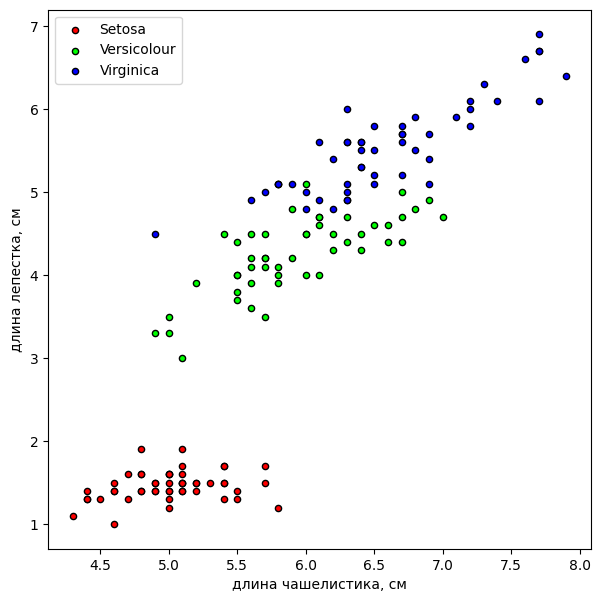

In [7]:
from matplotlib.colors import ListedColormap
cmap_bold = ListedColormap(['#FF0000',  '#00FF00', '#0000FF'])

K = 3
x = X[-1]

fig, ax = plt.subplots(figsize=(7,7))
for i, iris_class in enumerate(['Setosa', 'Versicolour', 'Virginica']):
    idx = y==i
    ax.scatter(X[idx,0], X[idx,2],
               c=cmap_bold.colors[i], edgecolor='k',
               s=20, label=iris_class);

ax.set(xlabel='длина чашелистика, см', ylabel='длина лепестка, см')
ax.legend();

## 3. Обучим модели дерево решений

### 3.1. Дерево решений с критерием "Индекс Джини"

In [8]:
# Создадим объект Decision Tree
clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=2, random_state=0)

# Обучение модели
clf_gini.fit(X_train, y_train)

# Прогноз на тестовых данных
y_pred_gini = clf_gini.predict(X_test)

In [9]:
# точность модели на тестовых данных
accuracy = accuracy_score(y_test, y_pred_gini)*100
print('Точность модели на тестовой выборке: ' + str(round(accuracy, 2)) + ' %.')

Точность модели на тестовой выборке: 97.78 %.


In [10]:
# посмотрим на метрики на обучающей выборке
y_pred_train_gini = clf_gini.predict(X_train)

accuracy = accuracy_score(y_train, y_pred_train_gini)*100
print('Точность модели на обучающей выборке: ' + str(round(accuracy, 2)) + ' %.')

Точность модели на обучающей выборке: 94.29 %.


### Визуализируем полученное дерево решений

[Text(0.4, 0.8333333333333334, 'x[3] <= 0.8\ngini = 0.664\nsamples = 105\nvalue = [31, 37, 37]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 31\nvalue = [31, 0, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[2] <= 4.75\ngini = 0.5\nsamples = 74\nvalue = [0, 37, 37]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.059\nsamples = 33\nvalue = [0, 32, 1]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.214\nsamples = 41\nvalue = [0, 5, 36]')]

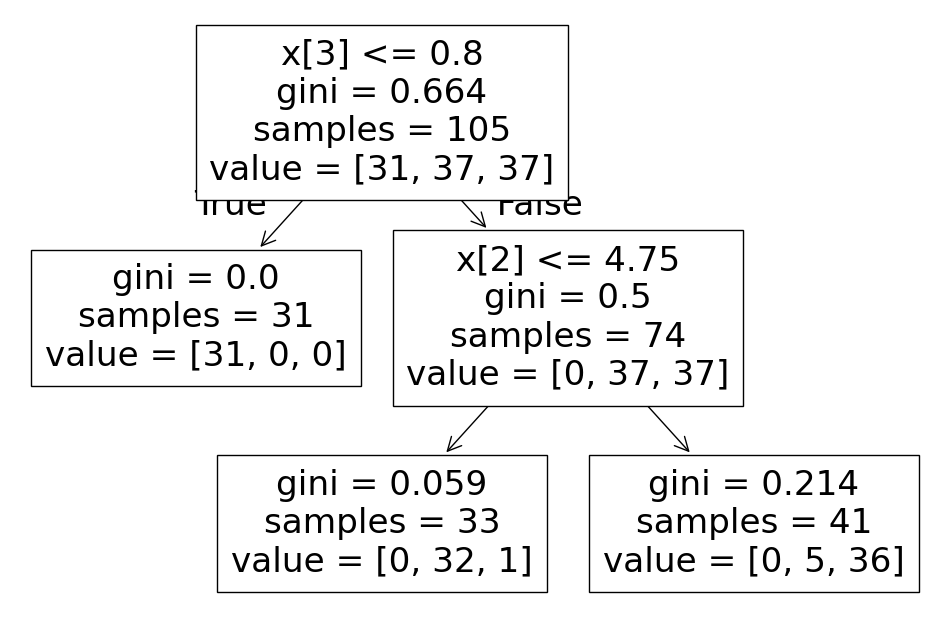

In [11]:
plt.figure(figsize=(12,8))

tree.plot_tree(clf_gini.fit(X_train, y_train))

А теперь давайте визуализируем границы классов. Для этого выберем первые 2 признака для обучения модели и покажем как выглядят границы принятия решения.

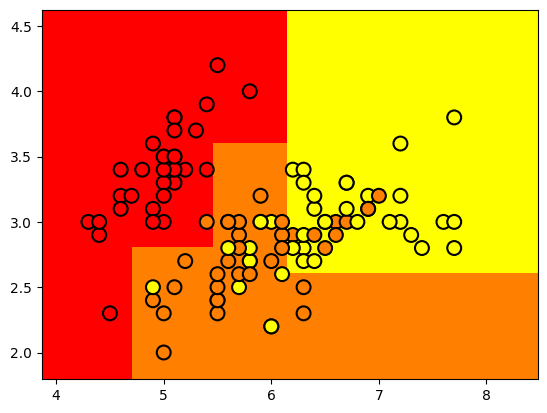

In [12]:
X_2d = X[:,0:2]

X_2d_train, X_2d_test, y_2d_train, y_2d_test = train_test_split(X_2d, y, test_size = 0.3, random_state = 42)

# Создадим объект Decision Tree
clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=0)

# Обучение модели
clf_gini.fit(X_2d_train, y_2d_train)

# Прогноз на тестовых данных
y_pred_gini = clf_gini.predict(X_2d_test)

# Напишем вспомогательную функцию, которая будет возвращать решетку для дальнейшей визуализации.
def get_grid(data):
    x_min, x_max = X_2d_train[:, 0].min()*0.9, X_2d_train[:, 0].max()*1.1
    y_min, y_max = X_2d_train[:, 1].min()*0.9, X_2d_train[:, 1].max()*1.1
    return np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

# немного кода для отображения разделяющей поверхности
xx, yy = get_grid(X_2d_test)
y_pred = clf_gini.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.pcolormesh(xx, yy, y_pred, cmap='autumn')
plt.scatter(X_2d_train[:, 0], X_2d_train[:, 1],
            c=y_2d_train, s=100, cmap='autumn',
            edgecolors='black', linewidth=1.5
);

### 3.2. Дерево решений с критерием "Информационная энтропия"

In [13]:
clf_en = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

# Обучение модели
clf_en.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

In [14]:
y_pred_en = clf_en.predict(X_test)

In [15]:
accuracy = accuracy_score(y_test, y_pred_en)*100
print('Точность модели на тестовой выборке: ' + str(round(accuracy, 2)) + ' %.')

Точность модели на тестовой выборке: 97.78 %.


In [16]:
# посмотрим на метрики на обучающей выборке
y_pred_train_en = clf_en.predict(X_train)

accuracy = accuracy_score(y_train, y_pred_train_en)*100
print('Точность модели на обучающей выборке: ' + str(round(accuracy, 2)) + ' %.')

Точность модели на обучающей выборке: 95.24 %.


### Визуализируем работу алгоритма

[Text(0.375, 0.875, 'x[3] <= 0.8\nentropy = 1.58\nsamples = 105\nvalue = [31, 37, 37]'),
 Text(0.25, 0.625, 'entropy = 0.0\nsamples = 31\nvalue = [31, 0, 0]'),
 Text(0.3125, 0.75, 'True  '),
 Text(0.5, 0.625, 'x[2] <= 4.75\nentropy = 1.0\nsamples = 74\nvalue = [0, 37, 37]'),
 Text(0.4375, 0.75, '  False'),
 Text(0.25, 0.375, 'x[3] <= 1.6\nentropy = 0.196\nsamples = 33\nvalue = [0, 32, 1]'),
 Text(0.125, 0.125, 'entropy = 0.0\nsamples = 32\nvalue = [0, 32, 0]'),
 Text(0.375, 0.125, 'entropy = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.75, 0.375, 'x[2] <= 5.15\nentropy = 0.535\nsamples = 41\nvalue = [0, 5, 36]'),
 Text(0.625, 0.125, 'entropy = 0.918\nsamples = 15\nvalue = [0, 5, 10]'),
 Text(0.875, 0.125, 'entropy = 0.0\nsamples = 26\nvalue = [0, 0, 26]')]

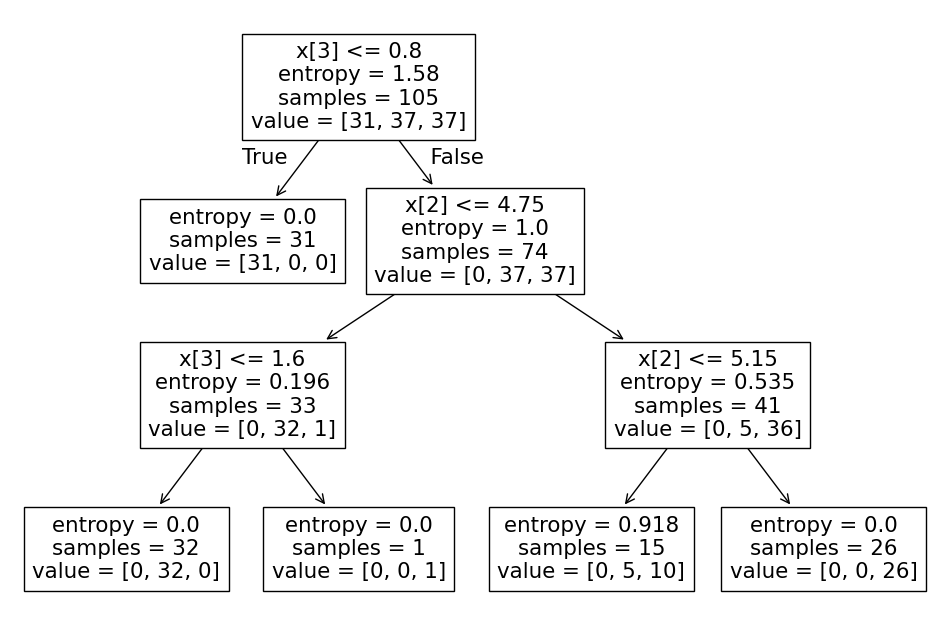

In [17]:
plt.figure(figsize=(12,8))

tree.plot_tree(clf_en.fit(X_train, y_train))

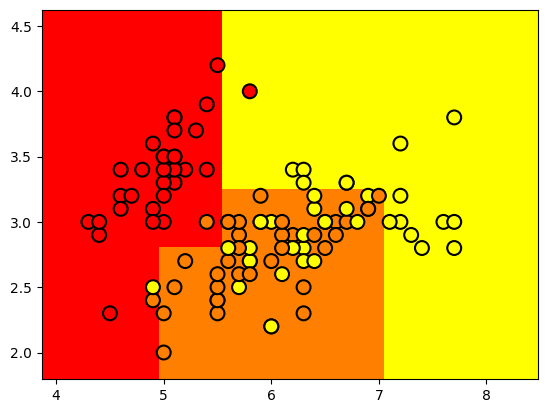

In [18]:
X_2d = X[:,0:2]

X_2d_train, X_2d_test, y_2d_train, y_2d_test = train_test_split(X_2d, y, test_size = 0.3, random_state = 42)

# Создадим объект Decision Tree
clf_en = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

# Обучение модели
clf_en.fit(X_2d_train, y_2d_train)

# Прогноз на тестовых данных
y_pred_gini = clf_en.predict(X_2d_test)

# Напишем вспомогательную функцию, которая будет возвращать решетку для дальнейшей визуализации.
def get_grid(data):
    x_min, x_max = X_2d_train[:, 0].min()*0.9, X_2d_train[:, 0].max()*1.1
    y_min, y_max = X_2d_train[:, 1].min()*0.9, X_2d_train[:, 1].max()*1.1
    return np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

# немного кода для отображения разделяющей поверхности
xx, yy = get_grid(X_2d_test)
y_pred = clf_en.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.pcolormesh(xx, yy, y_pred, cmap='autumn')
plt.scatter(X_2d_train[:, 0], X_2d_train[:, 1],
            c=y_2d_train, s=100, cmap='autumn',
            edgecolors='black', linewidth=1.5
);

## 4. Выведем отчет о моделях

In [19]:
print(classification_report(y_test, y_pred_en))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.92      0.96        13
           2       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



In [20]:
print(classification_report(y_test, y_pred_gini))

              precision    recall  f1-score   support

           0       1.00      0.89      0.94        19
           1       0.50      0.85      0.63        13
           2       0.33      0.15      0.21        13

    accuracy                           0.67        45
   macro avg       0.61      0.63      0.59        45
weighted avg       0.66      0.67      0.64        45



# 5. GridSearchCV

Как и в предыдущих алгоритмах, в решающих деревьях также много гиперпараметров, которые необходимо задать до обучения модели. Для выбора значений этих параметров также можно использовать `GridSearchCV`. Рассмотрим на хрестоматийном примере Титаник. Данные предварительно очищены и подготовлены для работы моделями.

- `Survived` - выжил/не выжил
- `Age` - возраст
- `Fare` - стоимость билета
- `C`,`Q` - порт посадки. Если оба значения =0, то третий порт `S`
- `Family` - наличие семьи на борту
- `Child`, `Female` - пол (М, Ж, ребенок). Если ни `Child` ни `Female`, то `Male`
- `Class_1`, `Class_2` - класс каюты. Если ни `Class_1` ни `Class_2`, тогда `Class_3`

In [25]:
# Чтение данных

df = pd.read_csv('train.csv')
df.to_pickle('titanic_clean.pickle')

titanic_dataframe = pd.read_pickle('titanic_clean.pickle')

In [26]:
titanic_dataframe.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [27]:
titanic_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [28]:
titanic_dataframe.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [29]:
# количество пропущенных значений
titanic_dataframe.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [30]:
X = titanic_dataframe.drop("Survived", axis=1)
y = titanic_dataframe["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2, random_state = 22)

> # Задание
>
> При помощи GridSearchCV найти наилучшее сочетание параметров `criterion`: ('gini', 'entropy'), `min_samples_split`: (3,5,8,10), `min_samples_leaf`: (1,3,5,7), `max_depth`: (3,4,5,6,7,8). Значения для DecisionTreeClassifier `max_features`='auto', `random_state`=22

In [32]:
# type your code here
parameters = {'criterion': ['gini', 'entropy'],
    'min_samples_split': [3, 5, 8, 10],
    'min_samples_leaf': [1, 3, 5, 7],
    'max_depth': [3, 4, 5, 6, 7, 8]
}

DTree = DecisionTreeClassifier(max_features='auto', random_state=22)

model = GridSearchCV(
    DTree,
    parameters,
    cv=5
)

model.fit(X_train, y_train)

print(model.best_params_)

ValueError: 
All the 960 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
960 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_validation.py", line 98, in validate_parameter_constraints
    raise InvalidParameterError(
sklearn.utils._param_validation.InvalidParameterError: The 'max_